# RetainIQ — Phase 4.3: Baseline Churn Modeling

## Objective

I build two reproducible baseline churn models:

1. Logistic Regression
2. Random Forest

I use the `Stayed` and `Churned` population, exclude direct outcome fields, use a stratified split,
and evaluate multiple classification metrics.

## 1. Connect to MySQL

In [1]:
from getpass import getpass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
from mysql.connector import Error
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

MYSQL_CONFIG = {
    "host": "localhost",
    "port": 3306,
    "user": "retainiq_user",
    "password": getpass("Enter MySQL password for retainiq_user: "),
    "database": "retainiq"
}

def get_connection():
    return mysql.connector.connect(**MYSQL_CONFIG)

def run_query(query, params=None):
    connection = None
    cursor = None
    try:
        connection = get_connection()
        cursor = connection.cursor(dictionary=True)
        cursor.execute(query, params or ())
        return pd.DataFrame(cursor.fetchall())
    except Error as exc:
        raise RuntimeError(f"MySQL query failed: {exc}") from exc
    finally:
        if cursor:
            cursor.close()
        if connection and connection.is_connected():
            connection.close()

print("MySQL analytical connection is ready.")

MySQL analytical connection is ready.


## 2. Pull the Modeling Dataset

In [2]:
model_query = '''
SELECT
    f.customer_id,
    f.tenure_months,
    f.monthly_charge,
    f.total_charges,
    f.total_refunds,
    f.total_revenue,
    f.satisfaction_score,
    f.cltv,
    d.gender,
    d.age,
    d.under_30,
    d.senior_citizen,
    d.married,
    d.dependents,
    d.number_of_dependents,
    a.quarter,
    a.referred_a_friend,
    a.number_of_referrals,
    a.offer,
    a.contract,
    a.paperless_billing,
    a.payment_method,
    a.total_extra_data_charges,
    a.total_long_distance_charges,
    s.phone_service,
    s.multiple_lines,
    s.internet_service,
    s.internet_type,
    s.online_security,
    s.online_backup,
    s.device_protection_plan,
    s.premium_tech_support,
    s.streaming_tv,
    s.streaming_movies,
    s.streaming_music,
    s.unlimited_data,
    s.avg_monthly_long_distance_charges,
    s.avg_monthly_gb_download,
    f.churn_label
FROM fact_customer_status f
JOIN dim_demographics d ON f.customer_id = d.customer_id
JOIN dim_account a ON f.customer_id = a.customer_id
JOIN dim_services s ON f.customer_id = s.customer_id
WHERE f.customer_status IN ('Stayed', 'Churned');
'''

model_df = run_query(model_query)
model_df["target"] = (model_df["churn_label"] == "Yes").astype(int)

print(f"Modeling rows: {len(model_df):,}")

Modeling rows: 6,589


## 3. Define X and y

In [3]:
X = model_df.drop(
    columns=["customer_id", "churn_label", "target"]
)

y = model_df["target"]

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 7
Categorical features: 30


## 4. Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")

Training rows: 5,271
Testing rows: 1,318


## 5. Preprocessing

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 6. Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

## 7. Logistic Regression Metrics

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

logistic_metrics = {
    "accuracy": accuracy_score(y_test, logistic_pred),
    "precision": precision_score(y_test, logistic_pred),
    "recall": recall_score(y_test, logistic_pred),
    "f1": f1_score(y_test, logistic_pred),
    "roc_auc": roc_auc_score(y_test, logistic_prob),
    "average_precision": average_precision_score(y_test, logistic_prob)
}

pd.Series(logistic_metrics).round(3)

accuracy            0.957
precision           0.912
recall              0.939
f1                  0.925
roc_auc             0.993
average_precision   0.985
dtype: float64

## 8. Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

## 9. Random Forest Metrics

In [9]:
rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred),
    "recall": recall_score(y_test, rf_pred),
    "f1": f1_score(y_test, rf_pred),
    "roc_auc": roc_auc_score(y_test, rf_prob),
    "average_precision": average_precision_score(y_test, rf_prob)
}

pd.Series(rf_metrics).round(3)

accuracy            0.869
precision           0.720
recall              0.885
f1                  0.794
roc_auc             0.948
average_precision   0.903
dtype: float64

## 10. Compare Models

In [10]:
model_comparison = pd.DataFrame(
    [logistic_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"]
).round(3)

model_comparison

,accuracy,precision,recall,f1,roc_auc,average_precision
Logistic Regression,0.957,0.912,0.939,0.925,0.993,0.985
Random Forest,0.869,0.720,0.885,0.794,0.948,0.903


## 11. ROC Curves

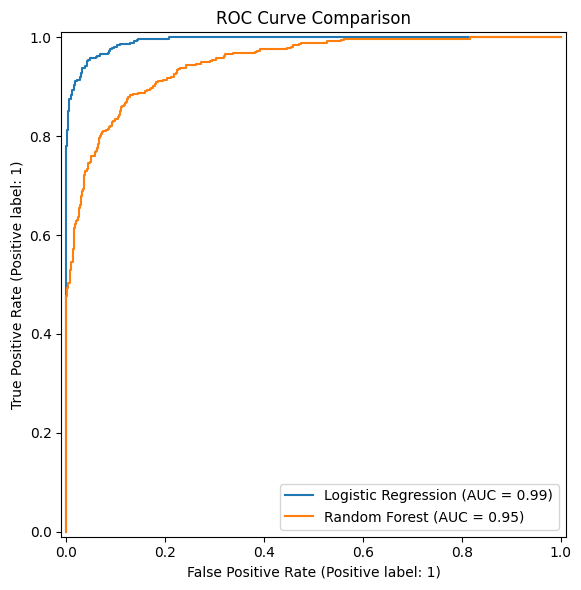

In [11]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, logistic_prob,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test, rf_prob,
    name="Random Forest",
    ax=ax
)

ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

## 12. Precision-Recall Curves

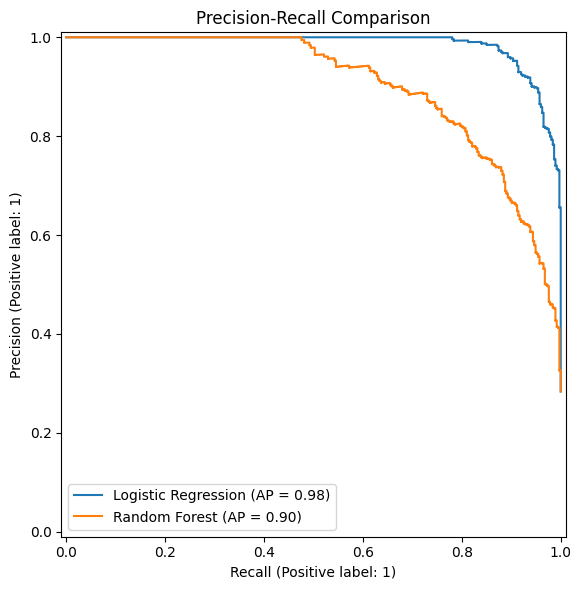

In [12]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test, logistic_prob,
    name="Logistic Regression",
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test, rf_prob,
    name="Random Forest",
    ax=ax
)

ax.set_title("Precision-Recall Comparison")
plt.tight_layout()
plt.show()

## 13. Confusion Matrix

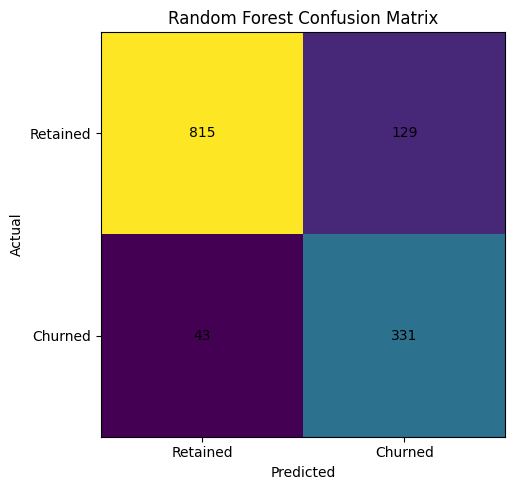

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Retained", "Churned"])
ax.set_yticklabels(["Retained", "Churned"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 14. Cross-Validation

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv = cross_val_score(
    logistic_pipeline, X, y, cv=cv, scoring="roc_auc"
)

rf_cv = cross_val_score(
    rf_pipeline, X, y, cv=cv, scoring="roc_auc"
)

cv_results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "mean_cv_roc_auc": [logistic_cv.mean(), rf_cv.mean()],
    "std_cv_roc_auc": [logistic_cv.std(), rf_cv.std()]
}).round(3)

cv_results

,model,mean_cv_roc_auc,std_cv_roc_auc
0,Logistic Regression,0.993,0.001
1,Random Forest,0.936,0.008


## 15. Metric Choice

I do not use accuracy alone because the target is imbalanced.

I track ROC AUC, precision, recall, F1, average precision, and the confusion matrix. Recall is
especially useful when the cost of missing a potential churner is high.

# Phase 4.3 Conclusion

I trained and evaluated two baseline churn models with reproducible preprocessing and stratified
validation.

**Next:** feature interpretation, error analysis, risk scoring, and business findings.